<a href="https://colab.research.google.com/github/0zzge/plant-disease-detection-cnn/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#25940A ;font-family:newtimeroman;color:white;font-size:300%;text-align:center;border-radius:60px 1px;">  Plant Disease Detection  </p>

In [ ]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download(
    'abdallahalidev/plantvillage-dataset'
)

print("Dataset path:", dataset_path)

print("Versions folder content:")
print(os.listdir(dataset_path))


100%|██████████| 2.04G/2.04G [01:11<00:00, 30.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3
Versions folder content:
['plantvillage dataset']


<div style="width:100%;text-align: center; background-color:#white;"> <img align=middle src="https://static.standard.co.uk/2021/07/26/17/Flowerbox-houseplants-collectionjpg?width=1200&auto=webp&quality=75" alt="Decision Tree" >


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#234D18;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Import libraries
</p>
</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')


In [ ]:

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix
import itertools
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import pathlib
import glob
import random
import os
import shutil


IMG_SIZE = (224, 224)
NUM_CLASSES = 38
SEED = 42
BATCH_SIZE = 128

BASE_PATH = "/kaggle/input/plantvillage-dataset"


DATA_DIR = pathlib.Path(BASE_PATH) / "plantvillage dataset/color"

all_image_paths = list(DATA_DIR.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths]
random.shuffle(all_image_paths)



class_names = sorted([item.name for item in DATA_DIR.glob('*') if item.name != "LICENSE.txt"])
label_to_index = dict((name, index) for index, name in enumerate(class_names))

all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths]

print(f"Number of total folder: {len(all_image_paths)}")
print(f"Number of class: {len(class_names)}")

Number of total folder: 0
Number of class: 0


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#234D18;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Read The Data
</p>
</div>

In [ ]:
import pathlib
import random # Ensure random is imported for shuffle

# The DATA_DIR in the previous cell was pointing to an incorrect location.
# Re-evaluating DATA_DIR and populating image paths and labels correctly.
# 'dataset_path' is assumed to be available from the initial download.
DATA_DIR = pathlib.Path(dataset_path) / "plantvillage dataset/color"

all_image_paths = list(DATA_DIR.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths]
random.shuffle(all_image_paths)

class_names = sorted([item.name for item in DATA_DIR.glob('*') if item.name != "LICENSE.txt"])
label_to_index = dict((name, index) for index, name in enumerate(class_names))

all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths]

print(f"Number of total images (re-evaluated): {len(all_image_paths)}")
print(f"Number of classes (re-evaluated): {len(class_names)}")

# Stratified Splitting

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_val_index, test_index in sss.split(all_image_paths, all_image_labels):
    train_val_paths = [all_image_paths[i] for i in train_val_index]
    train_val_labels = [all_image_labels[i] for i in train_val_index]
    test_paths = [all_image_paths[i] for i in test_index]
    test_labels = [all_image_labels[i] for i in test_index]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_index, val_index in sss2.split(train_val_paths, train_val_labels):
    train_paths = [train_val_paths[i] for i in train_index]
    train_labels = [train_val_labels[i] for i in train_index]
    val_paths = [train_val_paths[i] for i in val_index]
    val_labels = [train_val_labels[i] for i in val_index]

print(f"Train set size: {len(train_paths)}")
print(f"Validation set size: {len(val_paths)}")
print(f"Test set size: {len(test_paths)}")

# Data preprocessing function
def decode_img(img_path, label):
    # Upload image
    img = tf.io.read_file(img_path)
    # Resize
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # Scaling colors
    img = img / 255.0
    # One hot encoding
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))


def apply_data_augmentation(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(decode_img, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(apply_data_augmentation, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.map(decode_img, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.map(decode_img, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

print("The datasets were successfully prepared in a stratified form.")

Number of total images (re-evaluated): 54305
Number of classes (re-evaluated): 38
Train set size: 34755
Validation set size: 8689
Test set size: 10861
The datasets were successfully prepared in a stratified form.


In [ ]:
classes = class_names
classes

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#234D18;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
 Visualize Some Images
</p>
</div>

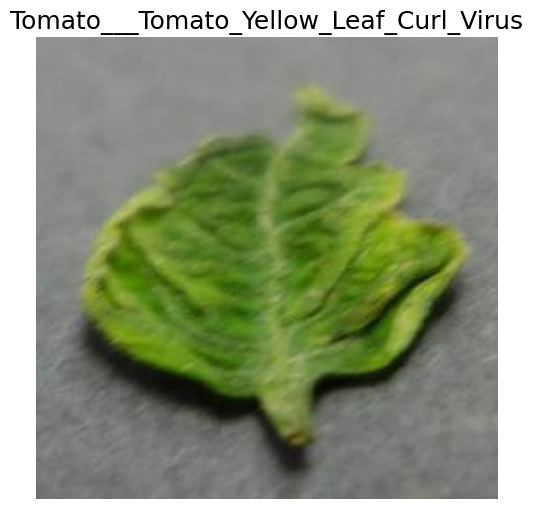

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Using a dynamically chosen path from the pre-loaded image paths
# This ensures the path is valid and accessible.
sample_image_index = 0 # You can change this index to view different images
img_path = all_image_paths[sample_image_index]
class_for_title = class_names[all_image_labels[sample_image_index]]

image = cv2.imread(img_path)


if image is None:
    raise ValueError(f"Image could not be loaded! Incorrect path.: {img_path}")

# OpenCV -> RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(class_for_title, size=18) # Dynamically set title
plt.axis("off")
plt.show()

----------------------------------

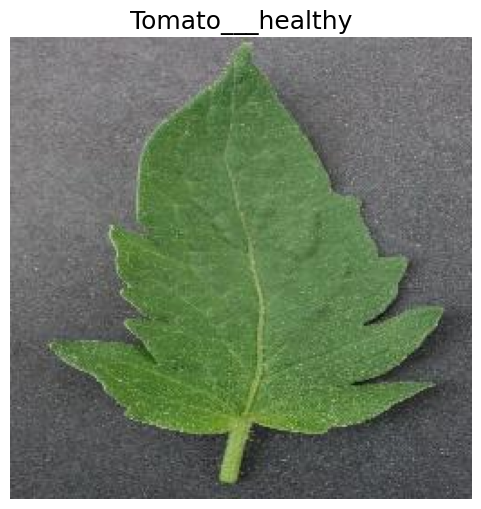

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Using a dynamically chosen path from the pre-loaded image paths
# This ensures the path is valid and accessible.
sample_image_index = 16 # You can change this index to view different images
img_path = all_image_paths[sample_image_index]
class_for_title = class_names[all_image_labels[sample_image_index]]

image = cv2.imread(img_path)


if image is None:
    raise ValueError(f"Image could not be loaded! Incorrect path: {img_path}")

# OpenCV -> RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(class_for_title, size=18) # Dynamically set title
plt.axis("off")
plt.show()

-----------------------------

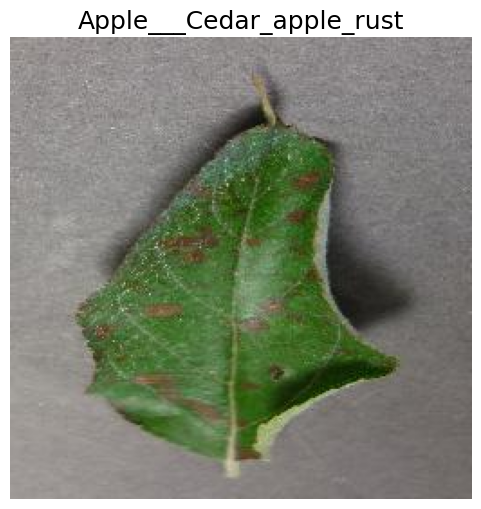

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Using a dynamically chosen path from the pre-loaded image paths
# This ensures the path is valid and accessible.
sample_image_index = 32 # You can change this index to view different images
img_path = all_image_paths[sample_image_index]
class_for_title = class_names[all_image_labels[sample_image_index]]

image = cv2.imread(img_path)


if image is None:
    raise ValueError(f"Image could not be loaded! Incorrect path: {img_path}")

# OpenCV -> RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(class_for_title, size=18) # Dynamically set title
plt.axis("off")
plt.show()

----------------------------------------
<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#234D18;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Build Neural network [CNN]
</p>
</div>

In [ ]:
# Transfer Learning Model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
#(Dense Layer)
x = Dense(1024, activation='relu')(x)
# %50 Dropout (to prevent Overfitting)
x = Dropout(0.5)(x)
# Output layer
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=predictions)
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

print("The Transfer Learning (MobileNetV2) model was successfully defined and compiled.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,608,678 (13.77 MB)

 Trainable params: 1,350,694 (5.15 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

The Transfer Learning (MobileNetV2) model was successfully defined and compiled.


In [ ]:
#model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )


In [ ]:
# model.summary()

-------------------------------
<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#234D18;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Train Our Model
</p>
</div>

In [ ]:
# Overfitting Control with Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# FIX: Recompile the model with the correct loss function for one-hot encoded labels
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Model Training
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping]
)

Epoch 1/20
125/272 ━━━━━━━━━━━━━━━━━━━━ 1:09:45 28s/step - accuracy: 0.3284 - loss: 2.7355

In [ ]:
print("Evaluating the model on the test set...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


plot_training_history(history)


y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred_probs.extend(model.predict(images))


y_pred = tf.argmax(y_pred_probs, axis=1).numpy()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


# Visualize Confusion Matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print("Non-normalized Confusion Matrix")

    plt.figure(figsize=(20, 20))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


# Plot normalized Confusion Matrix
plot_confusion_matrix(
    cm,
    classes=class_names,
    normalize=True,
    title='Plant Disease Detection - Normalized Confusion Matrix'
)


In [ ]:
accuracy = history.history['accuracy']
loss = history.history['loss']
epochs = range(1,21)

plt.plot(epochs , accuracy , label = 'Accuracy')
plt.plot(epochs , loss , label = 'loss')
plt.legend()
plt.show()

In [ ]:
mobilenet_loss, mobilenet_acc = model.evaluate(test_ds, verbose=0)
print("MobileNetV2 Test Accuracy:", mobilenet_acc)
print("MobileNetV2 Test Loss:", mobilenet_loss)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from itertools import cycle


print("Predictions are being generated, please wait....")
y_true = []
y_pred_probs = []


for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print("Estimation process completed.")

In [ ]:
# Multi-Class ROC Curve
n_classes = len(classes)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate ')
plt.title('Multiclass ROC')
plt.legend(loc="lower right", fontsize='small')
plt.show()

In [ ]:
# Calculating Metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_labels, average='macro')
accuracy = accuracy_score(y_true, y_pred_labels)

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

# Comparison of Metrics (Bar Chart)
plt.figure(figsize=(8, 6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.ylim(0, 1.1)
plt.title('Model Performance Metrics Comparison')
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.ylabel('Skor')
plt.show()


print("\n--- Detailed Class-Based Report---")
print(classification_report(y_true, y_pred_labels, target_names=classes))

------------------------------------------
<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#234D18;
           font-size:200%;
           font-family:Serif;
           letter-spacing:0.5px">

<p style="padding: 10px;
          color:white;
          font-size:120%;
          text-align:center;">
Test model predictions
</p>
</div>

In [ ]:
def img_to_pred(image):
  image = image.numpy()
  image = tf.expand_dims(image,0)
  return image

In [ ]:
plt.figure(figsize=(18,18))
for images, labels in test_ds.take(1) : # take the first patch
  for i in range(min(BATCH_SIZE, 9)): # Limit to 9 images for 3x3 subplot
    # Ensure i is within the bounds of the batch
    if i >= images.shape[0]:
        break
    plt.subplot(3,3,i+1) # Use i+1 for subplot index
    plt.imshow(images[i].numpy().astype('float32'))
    plt.axis('off')
    actual = classes[tf.argmax(labels[i]).numpy()]
    predict =classes[np.argmax( model.predict(img_to_pred(images[i])))]
    plt.title(f"actual : {actual}  \n predicted : {predict} ")
plt.tight_layout()
plt.show()

--------------------------
<p style="padding: 10px;
          color:#25940A ;
          font-size:240%;
          font-family:Serif;
          text-align:center;">   
Thanks For Reading !
</p>

In [ ]:
# ================================
# Baseline CNN Model - for Comparison
# ================================

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(38, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# Train baseline
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

# Evaluate baseline
baseline_loss, baseline_acc = baseline_model.evaluate(test_ds, verbose=0)

print(f"Baseline CNN Test Accuracy: {baseline_acc:.4f}")

In [ ]:
# ======================================
# Baseline vs Transfer Learning Comparison
# ======================================

print("Model Comparison on Test Set")
print("-" * 40)
print(f"Baseline CNN  - Loss: {baseline_loss:.4f} | Acc: {baseline_acc:.4f}")
print(f"MobileNetV2   - Loss: {mobilenet_loss:.4f} | Acc: {mobilenet_acc:.4f}")
print("-" * 40)
print(f"Accuracy Improvement: {(mobilenet_acc - baseline_acc)*100:.2f}%")